# Exploratory Data Analysis

Let's get familiar with the credit scoring dataset before we start modeling. 3000 loan applications, 28 features, binary target (good/bad loan).

In [11]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from src.data_loader import load_raw_data, get_feature_target
from src.config import CONFIG

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 35)
%matplotlib inline

## Loading the data

In [12]:
df = load_raw_data()
print(f"Shape: {df.shape}")
df.head(10)

Shape: (3000, 29)


,TARGET,DerogCnt,CollectCnt,BanruptcyInd,InqCnt06,InqTimeLast,InqFinanceCnt24,TLTimeFirst,TLTimeLast,TLCnt03,TLCnt12,TLCnt24,TLCnt,TLSum,TLMaxSum,TLSatCnt,TLDel60Cnt,TLBadCnt24,TL75UtilCnt,TL50UtilCnt,TLBalHCPct,TLSatPct,TLDel3060Cnt24,TLDel90Cnt24,TLDel60CntAll,TLOpenPct,TLBadDerogCnt,TLDel60Cnt24,TLOpen24Pct
0,1,3,3,0,4,0.0,5,117,27,0,0,0,5.0,19410.0,21147.0,16.0,2,1,3.0,3.0,0.9179,0.2083,2,3,7,0.2083,4,4,0.0000
1,1,15,9,0,3,1.0,3,14,14,0,0,1,1.0,16776.0,20971.0,1.0,0,0,1.0,1.0,0.8000,0.0000,0,0,0,1.0000,12,0,1.0000
2,1,0,0,0,1,5.0,1,354,7,0,2,10,19.0,16903.0,47593.0,21.0,1,1,4.0,5.0,0.3552,0.6538,0,1,1,0.7308,1,1,0.5263
3,1,8,5,0,6,1.0,10,16,4,0,2,4,3.0,18339.0,20093.0,1.0,1,0,2.0,3.0,0.9127,0.2500,1,1,1,0.7500,7,1,1.3333
4,1,3,1,0,9,0.0,8,130,52,0,0,0,1.0,2327.0,1860.0,3.0,4,1,1.0,1.0,1.2511,0.0000,0,1,4,0.1429,3,1,0.0000
5,1,1,1,1,2,2.0,0,124,3,1,4,5,5.0,5961.0,5800.0,5.0,2,0,4.0,4.0,1.0278,0.5000,0,0,2,0.6250,0,0,1.0000
6,1,0,0,0,1,3.0,1,148,10,0,2,6,14.0,55642.0,77854.0,24.0,0,0,7.0,9.0,0.7147,0.5926,3,0,0,0.5185,0,0,0.4286
7,1,3,2,0,5,1.0,3,124,2,1,4,6,7.0,14577.0,21638.0,12.0,0,0,4.0,4.0,0.6737,0.5333,2,0,2,0.4667,1,1,0.8571
8,1,1,1,0,2,0.0,3,286,6,0,2,6,6.0,26853.0,33562.0,5.0,6,2,3.0,4.0,0.8001,0.1538,1,5,6,0.4615,5,5,1.0000
9,1,0,0,0,0,15.0,0,175,25,0,0,0,10.0,36424.0,61036.0,17.0,1,0,4.0,5.0,0.5968,0.6111,1,0,1,0.5556,0,0,0.0000


In [13]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
TARGET,3000.0,0.17,0.37,0.0,0.00,0.00,0.00,1.00
DerogCnt,3000.0,1.43,2.73,0.0,0.00,0.00,2.00,51.00
CollectCnt,3000.0,0.86,2.16,0.0,0.00,0.00,1.00,50.00
BanruptcyInd,3000.0,0.15,0.36,0.0,0.00,0.00,0.00,1.00
InqCnt06,3000.0,3.11,3.48,0.0,1.00,2.00,4.00,40.00
InqTimeLast,2812.0,3.11,4.64,0.0,1.00,1.00,3.00,24.00
InqFinanceCnt24,3000.0,3.56,4.48,0.0,1.00,2.00,5.00,48.00
TLTimeFirst,3000.0,170.11,92.81,6.0,106.00,151.00,227.00,933.00
TLTimeLast,3000.0,11.87,16.32,0.0,4.00,7.00,13.00,342.00
TLCnt03,3000.0,0.28,0.58,0.0,0.00,0.00,0.00,7.00


In [14]:
df.dtypes.value_counts()

int64      18
float64    11
Name: count, dtype: int64

All numeric — makes sense for credit bureau data. No categorical features to worry about.

## Missing values

Let's see how bad it is.

In [15]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Pct': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)
print(f"{len(missing_df)} features have missing values out of {df.shape[1]}")
missing_df

11 features have missing values out of 29


,Count,Pct
InqTimeLast,188,6.27
TL75UtilCnt,99,3.30
TL50UtilCnt,99,3.30
TLBalHCPct,41,1.37
TLSum,40,1.33
TLMaxSum,40,1.33
TLSatCnt,4,0.13
TLSatPct,4,0.13
TLCnt,3,0.10
TLOpenPct,3,0.10


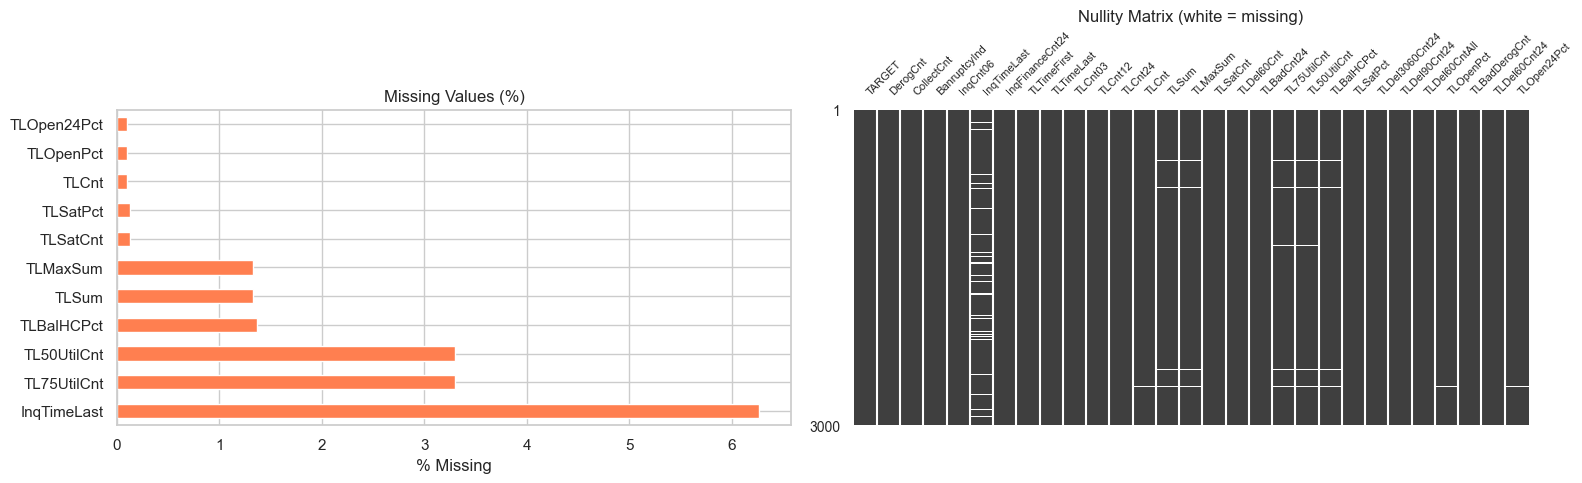

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

missing_df['Pct'].plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Missing Values (%)')
axes[0].set_xlabel('% Missing')

msno.matrix(df, ax=axes[1], sparkline=False, fontsize=8)
axes[1].set_title('Nullity Matrix (white = missing)')

plt.tight_layout()
plt.savefig('../reports/figures/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

Not too bad — `InqTimeLast` is the worst at ~6%. These are probably applicants with no inquiry history so the field is just blank. That's actually informative, not random. We'll use median imputation later (more robust than mean given the outliers).

## Target variable

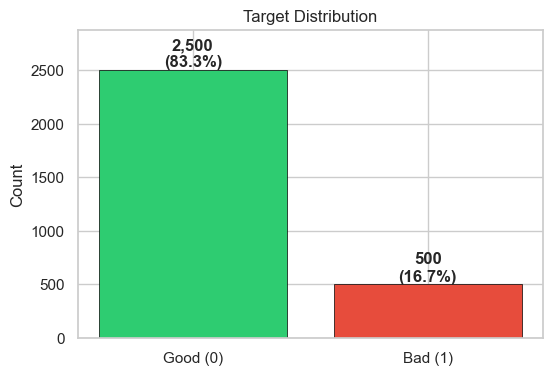

Imbalance ratio: 5.0:1


In [17]:
target = CONFIG['target_column']
target_counts = df[target].value_counts()
target_pct = df[target].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Good (0)', 'Bad (1)'], target_counts.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count:,}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('Count')
ax.set_title('Target Distribution')
ax.set_ylim(0, target_counts.max() * 1.15)
plt.savefig('../reports/figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Imbalance ratio: {target_counts.iloc[0] / target_counts.iloc[1]:.1f}:1")

**This is important.** 83/17 split means if you just predict "good" for everyone, you get 83.3% accuracy. That's basically what the original model was doing — its "82.83% accuracy" was actually *worse* than the dumb baseline. Need to use ROC-AUC and recall instead.

## Feature distributions by target

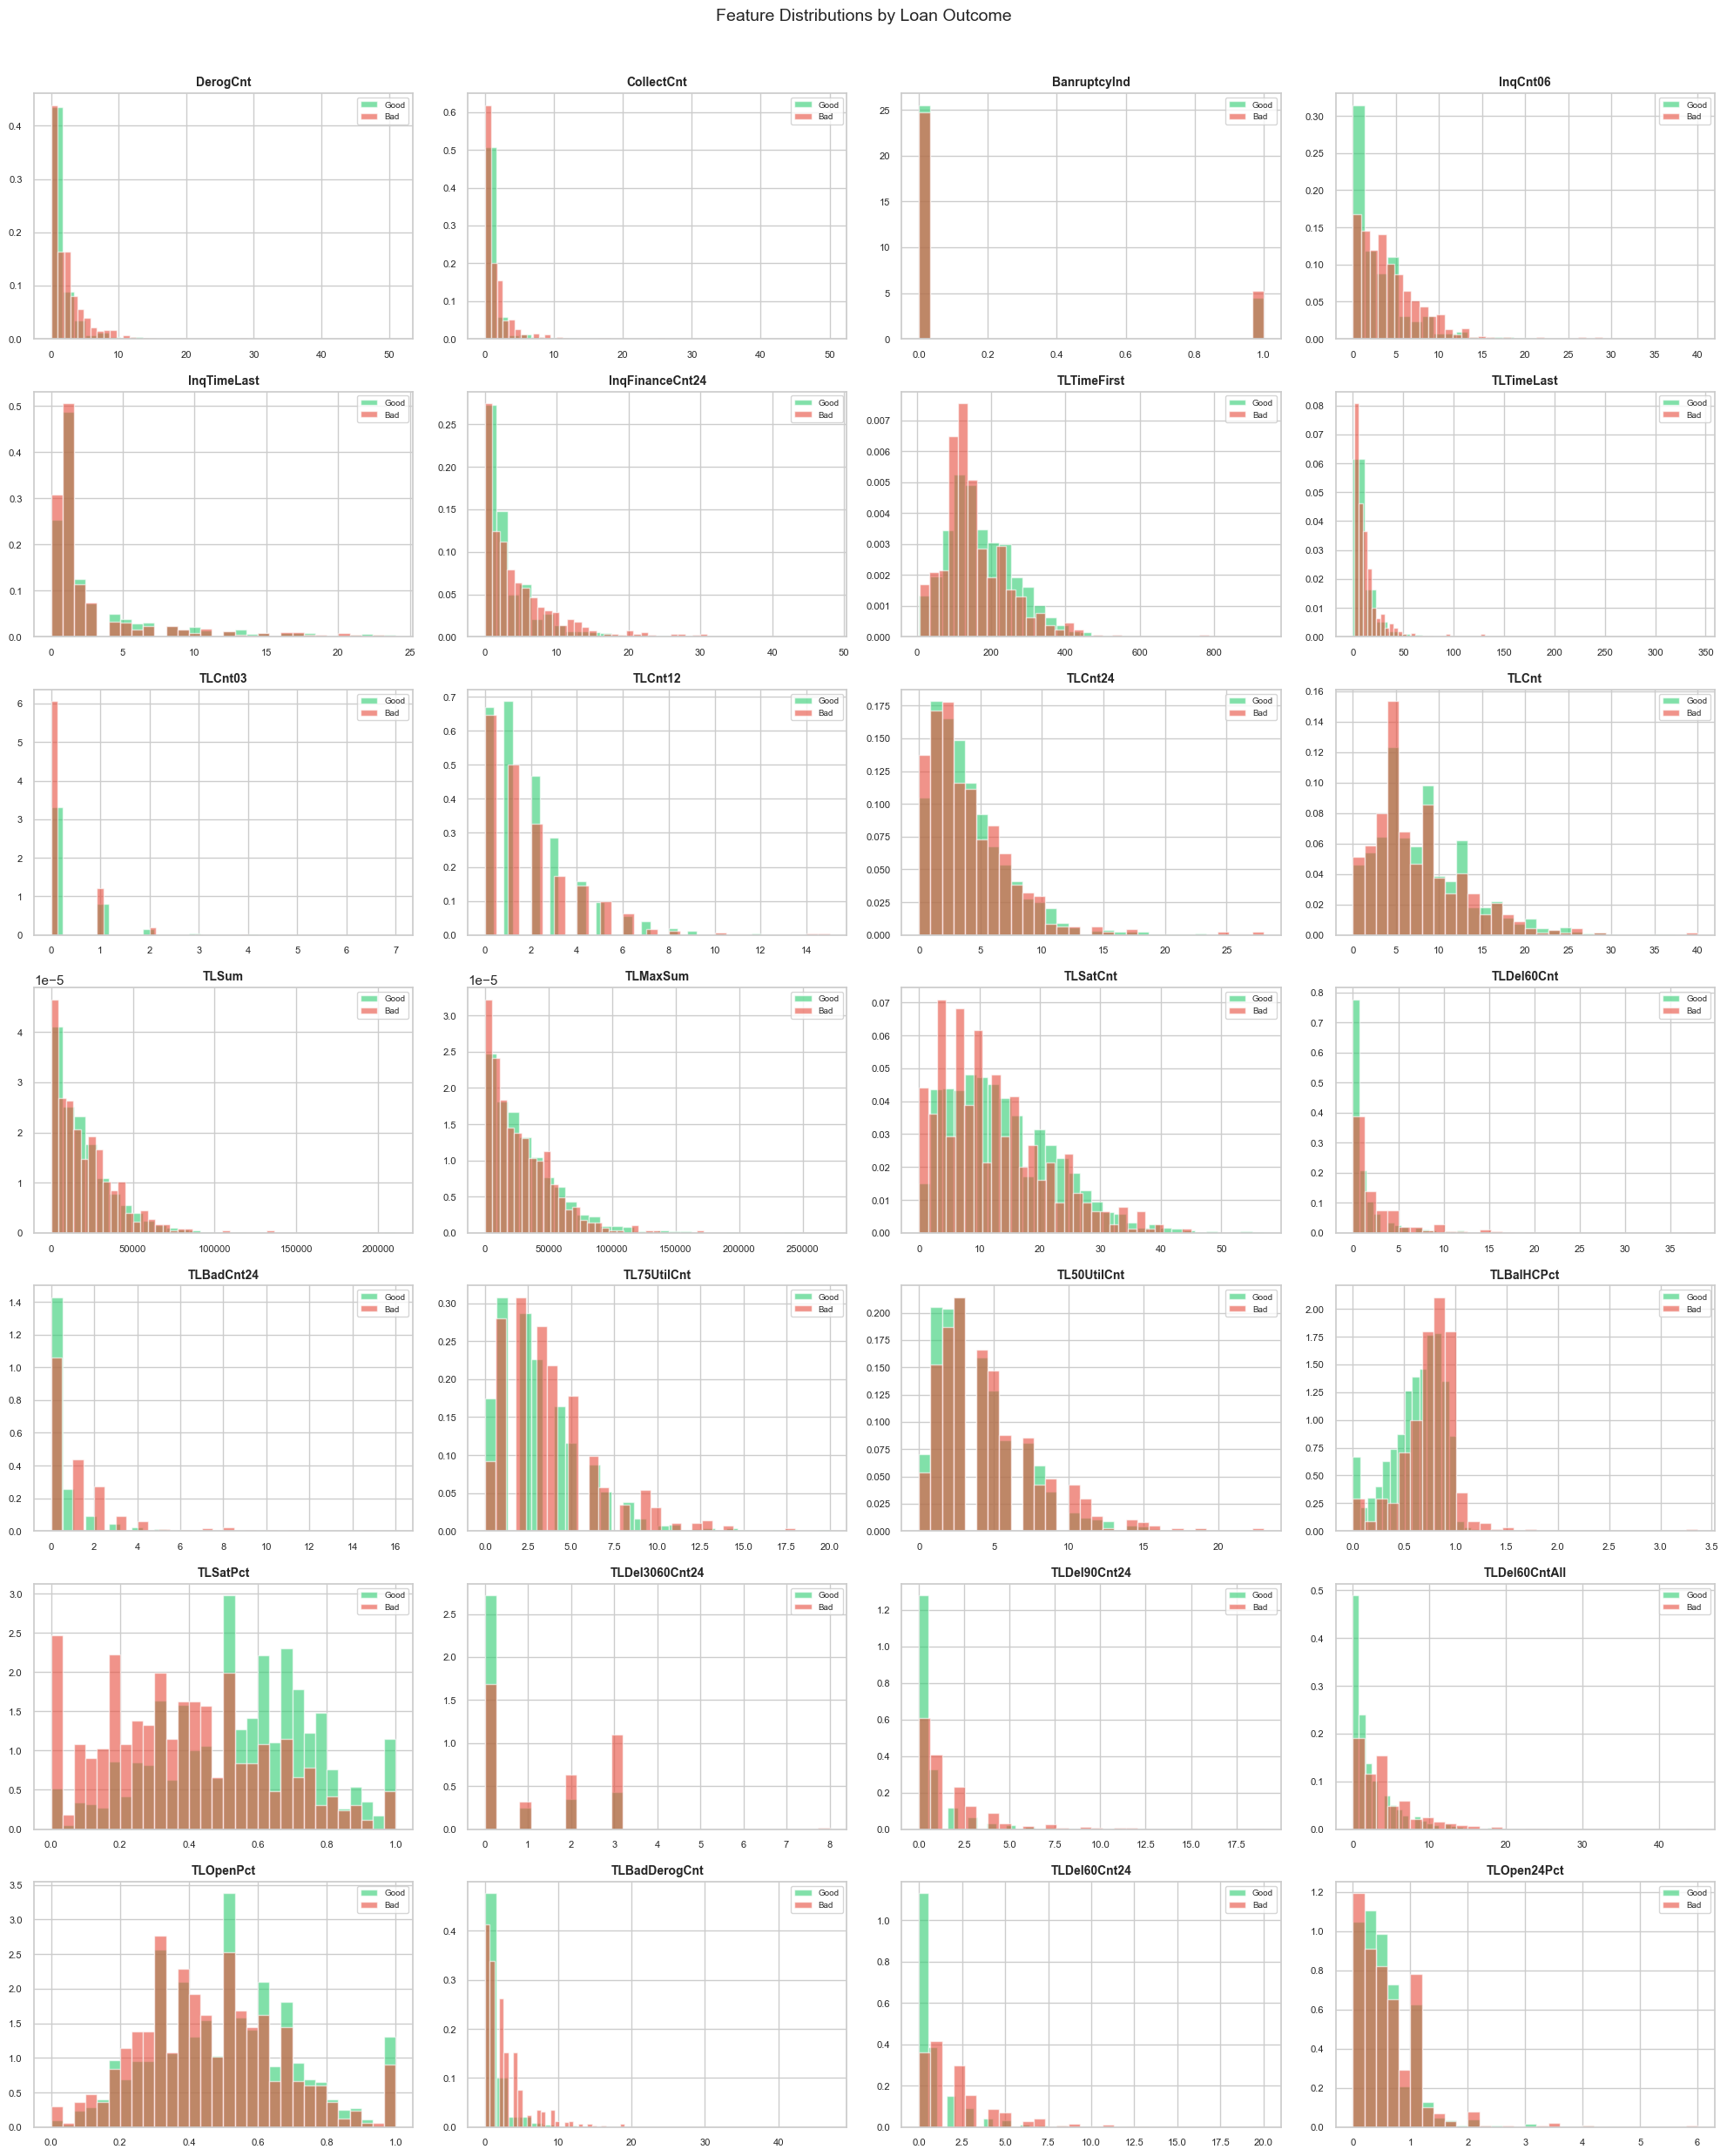

In [18]:
X, y = get_feature_target(df)
features = X.columns.tolist()

ncols = 4
nrows = int(np.ceil(len(features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    for label, color, name in [(0, '#2ecc71', 'Good'), (1, '#e74c3c', 'Bad')]:
        subset = df[df[target] == label][feat].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Loan Outcome', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Some clear winners here — the delinquency features (`TLDel60CntAll`, `DerogCnt`, etc.) show really nice separation between good and bad. The count features are super skewed though.

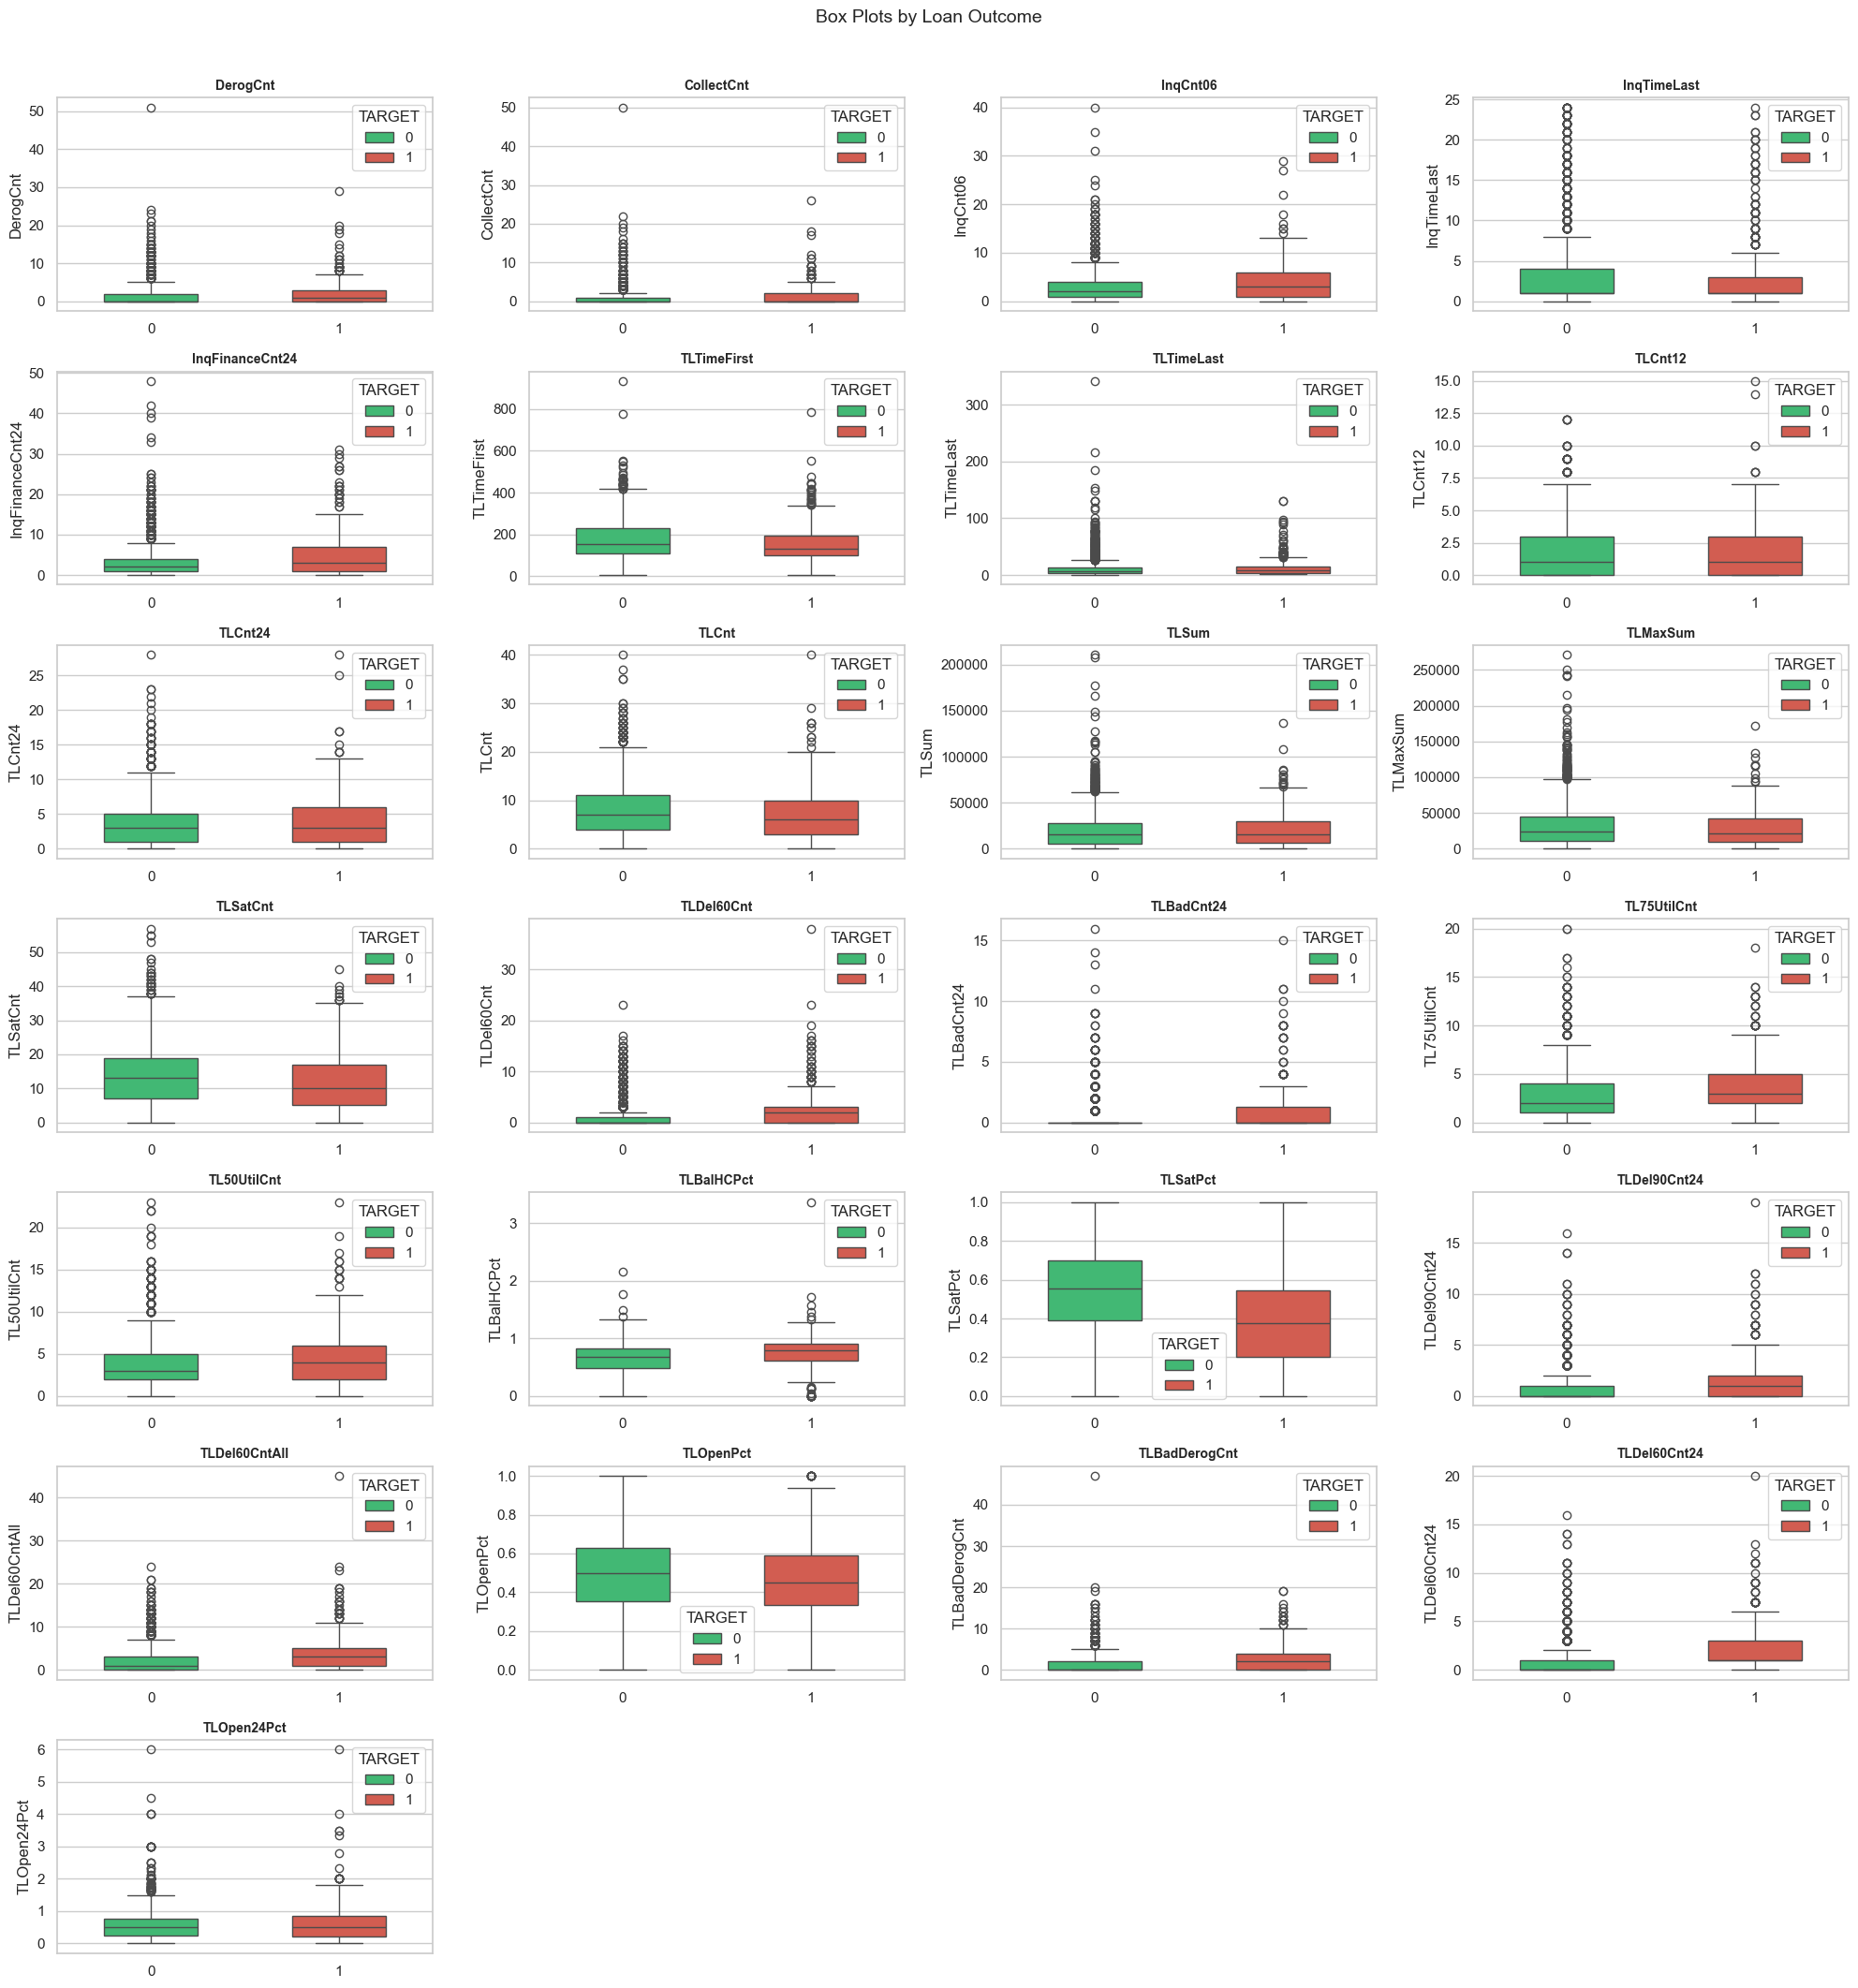

In [20]:
# box plots — easier to see the difference for some of these
continuous_feats = [f for f in features if df[f].nunique() > 10]

ncols = 4
nrows = int(np.ceil(len(continuous_feats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3))
axes = axes.flatten()

for i, feat in enumerate(continuous_feats):
    sns.boxplot(data=df, x=target, y=feat, ax=axes[i],
                palette={0: '#2ecc71', 1: '#e74c3c'}, width=0.5, hue=target)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(len(continuous_feats), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots by Loan Outcome', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/boxplots_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlations

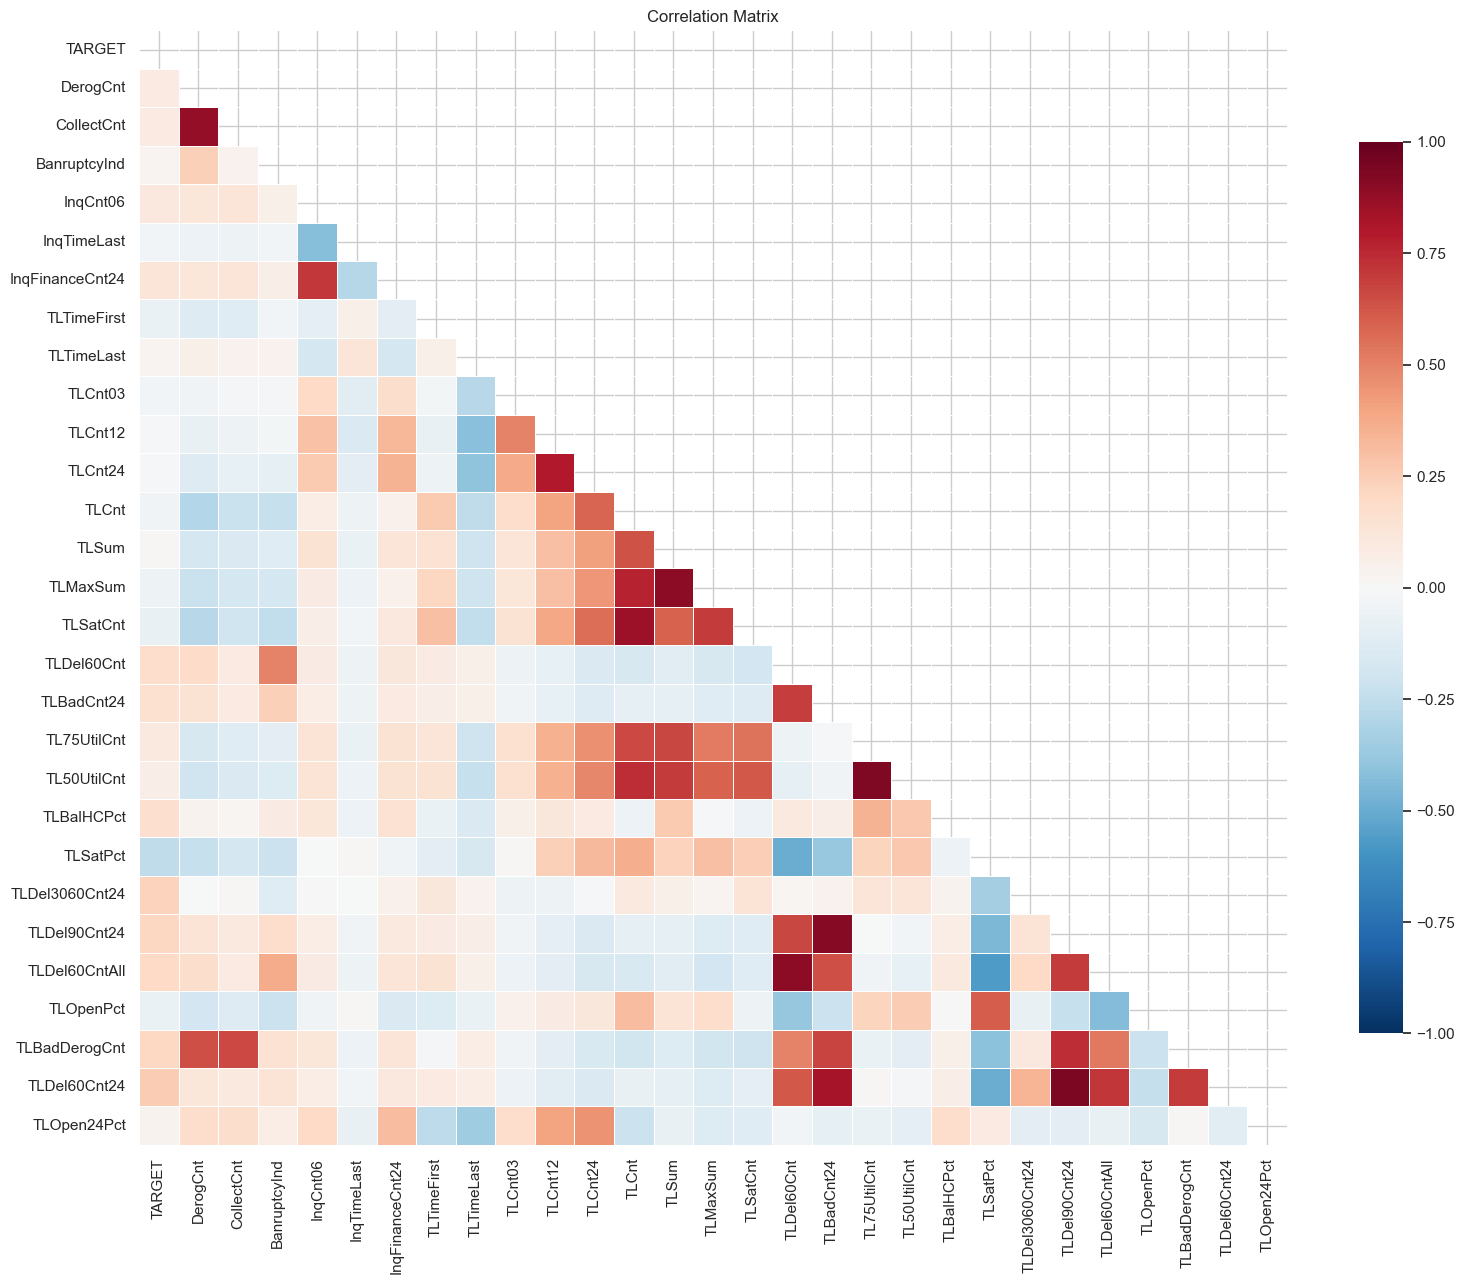

In [21]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# which pairs are highly correlated? need to deal with these later
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.8:
            high_corr.append((corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)))

print("Pairs with |r| > 0.8:")
for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {f1:20s} <-> {f2:20s}  r={r}")

Pairs with |r| > 0.8:
  TLDel90Cnt24         <-> TLDel60Cnt24          r=0.945
  TL75UtilCnt          <-> TL50UtilCnt           r=0.933
  TLBadCnt24           <-> TLDel90Cnt24          r=0.911
  TLDel60Cnt           <-> TLDel60CntAll         r=0.896
  TLSum                <-> TLMaxSum              r=0.892
  DerogCnt             <-> CollectCnt            r=0.88
  TLCnt                <-> TLSatCnt              r=0.855
  TLBadCnt24           <-> TLDel60Cnt24          r=0.83


Lots of multicollinearity — makes sense, many of these features are measuring the same underlying thing (e.g. delinquency at different time windows). Will need to address this in feature engineering.

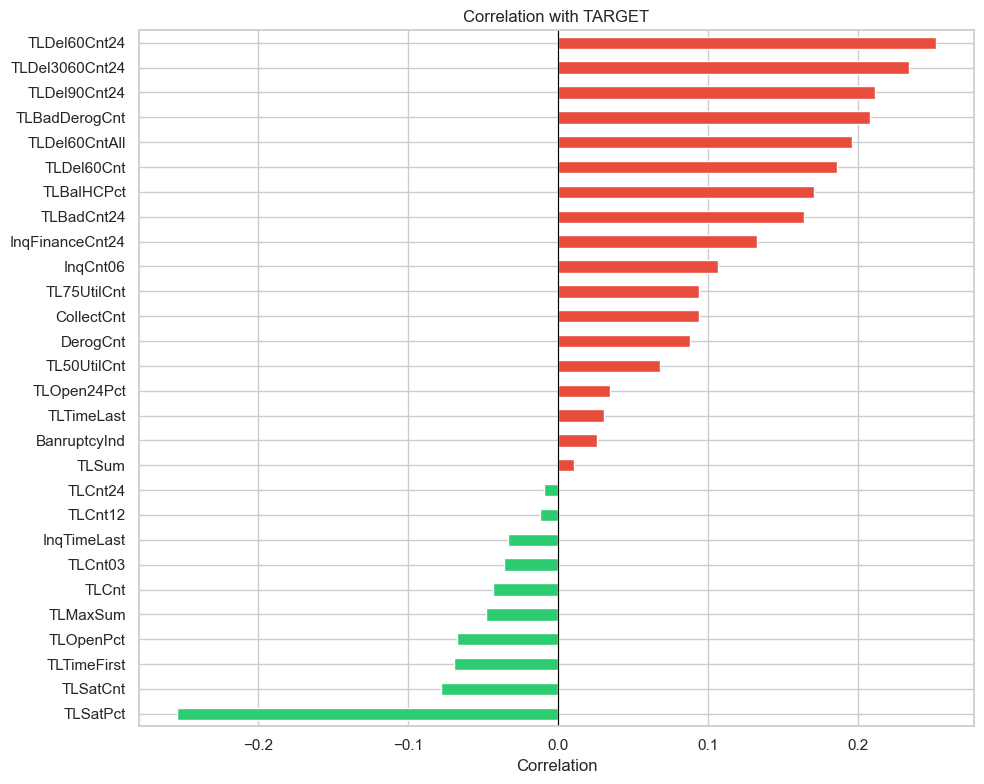

In [23]:
# which features correlate most with the target?
target_corr = df.corr()[target].drop(target).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Correlation with TARGET')
ax.set_xlabel('Correlation')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../reports/figures/correlation_with_target.png', dpi=150, bbox_inches='tight')
plt.show()

## Outliers

Quick check — but I don't think we should remove outliers here. Someone with 15 delinquent trade lines isn't an error, they're just really high risk.

In [24]:
outlier_summary = []
for feat in features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        outlier_summary.append({'Feature': feat, 'Outliers': n_out,
                                'Pct': round(n_out/len(df)*100, 1)})

pd.DataFrame(outlier_summary).sort_values('Outliers', ascending=False)

,Feature,Outliers,Pct
8,TLCnt03,668,22.3
2,BanruptcyInd,460,15.3
4,InqTimeLast,434,14.5
24,TLDel60Cnt24,418,13.9
21,TLDel90Cnt24,303,10.1
1,CollectCnt,297,9.9
7,TLTimeLast,268,8.9
15,TLDel60Cnt,245,8.2
3,InqCnt06,205,6.8
16,TLBadCnt24,190,6.3


Yeah, not going to remove these. Tree models handle outliers fine, and the WoE binning will group extreme values together anyway.

## Bad rate by decile

For the top features, let's see if the bad rate actually increases when the feature value increases. This is basically a preview of what the WoE analysis will formalize.

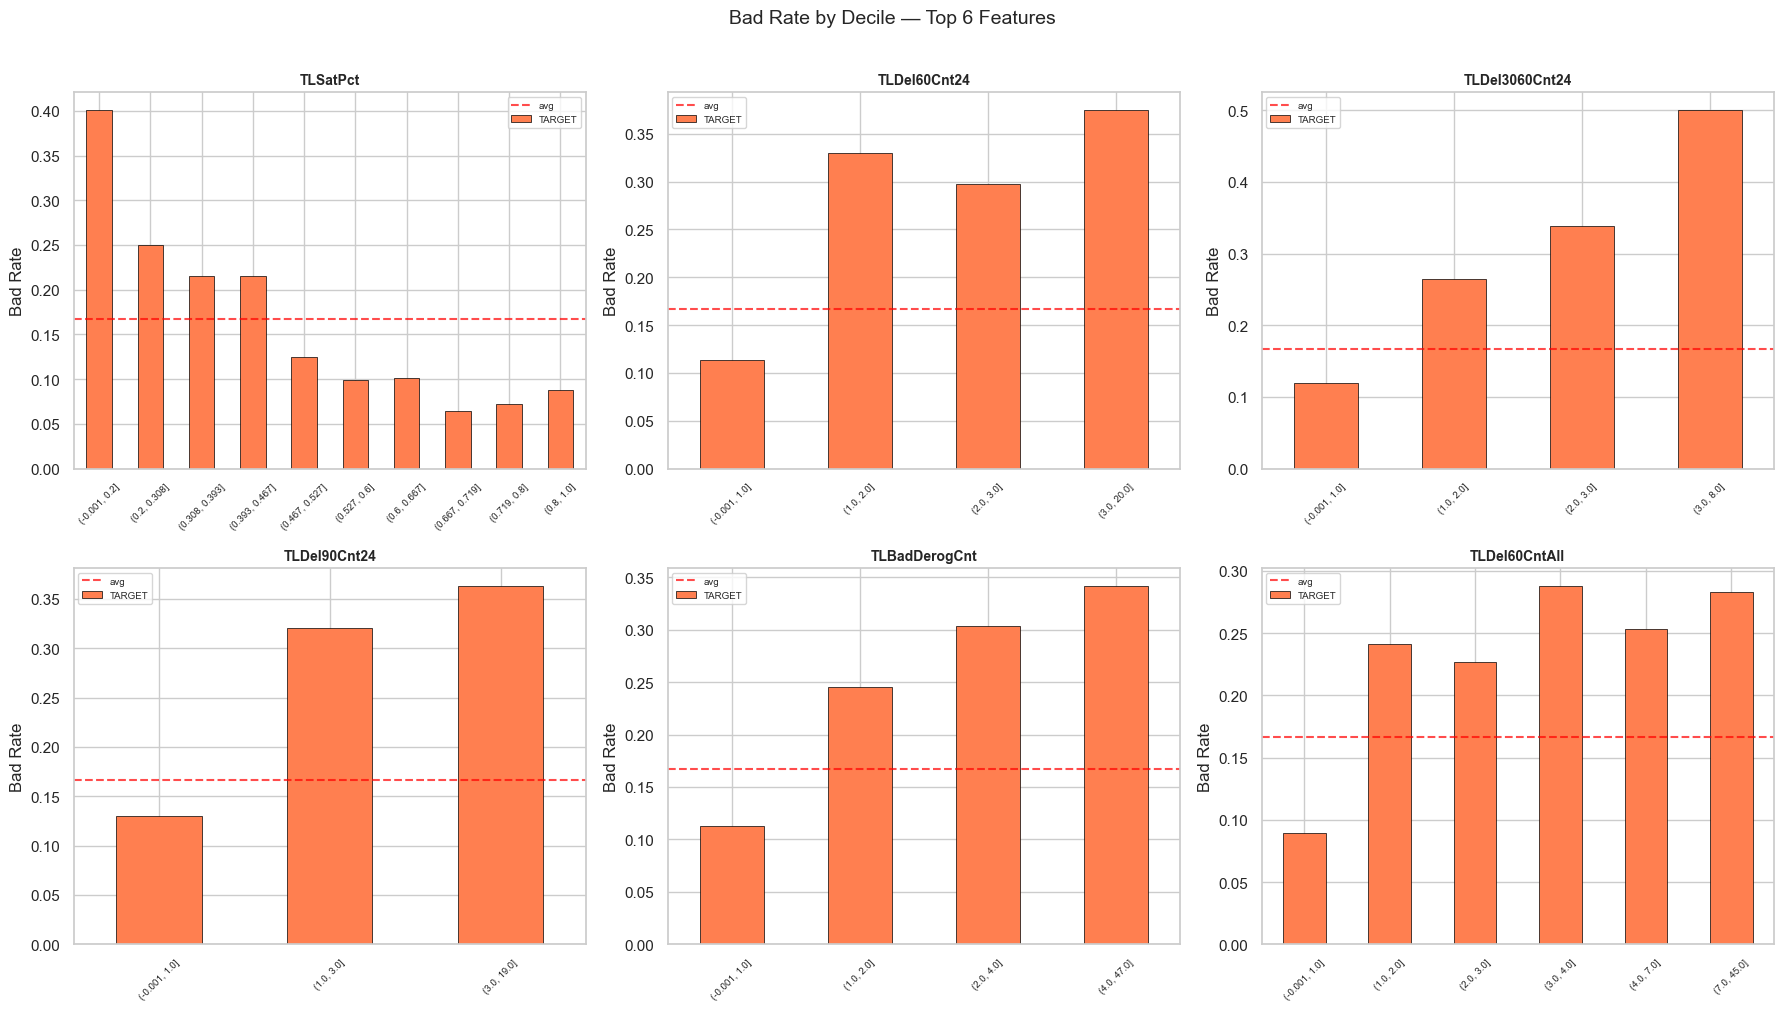

In [25]:
top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    try:
        df['_bin'] = pd.qcut(df[feat], q=10, duplicates='drop')
    except ValueError:
        df['_bin'] = pd.cut(df[feat], bins=10)
    
    bad_rate = df.groupby('_bin', observed=True)[target].mean()
    bad_rate.plot(kind='bar', ax=ax, color='coral', edgecolor='black', linewidth=0.5)
    ax.set_title(f'{feat}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Bad Rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.axhline(y=df[target].mean(), color='red', linestyle='--', alpha=0.7, label='avg')
    ax.legend(fontsize=7)

df.drop(columns=['_bin'], inplace=True)
plt.suptitle('Bad Rate by Decile — Top 6 Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/bad_rate_by_decile.png', dpi=150, bbox_inches='tight')
plt.show()

## Group means

In [26]:
group_means = df.groupby(target).mean().T
group_means.columns = ['Good', 'Bad']
group_means['Diff'] = group_means['Bad'] - group_means['Good']
group_means['Diff_%'] = ((group_means['Diff'] / group_means['Good'].replace(0, np.nan)) * 100).round(1)
group_means.round(2).sort_values('Diff_%', ascending=False)

,Good,Bad,Diff,Diff_%
TLDel60Cnt24,0.86,2.09,1.22,141.2
TLDel90Cnt24,0.66,1.58,0.91,137.9
TLBadCnt24,0.47,1.05,0.58,123.8
TLDel3060Cnt24,0.60,1.33,0.73,120.7
TLBadDerogCnt,1.18,2.55,1.37,116.4
TLDel60Cnt,1.29,2.69,1.40,108.8
TLDel60CntAll,2.22,4.01,1.79,80.5
CollectCnt,0.77,1.31,0.54,70.9
DerogCnt,1.32,1.97,0.65,48.8
InqFinanceCnt24,3.29,4.88,1.59,48.4


## Takeaways

- **83/17 class imbalance** — accuracy is useless as a metric, need ROC-AUC and recall
- **Delinquency features are strongest** — TLDel60CntAll, DerogCnt, TLBadDerogCnt all show clear separation
- **Lots of correlated features** — will need to drop some or use VIF. Many are just the same concept at different time windows
- **Missing data is informative** — no inquiry = no InqTimeLast, that's not random
- **Don't remove outliers** — extreme values are real and useful for prediction
- **Original model was basically useless** — 82.83% accuracy is worse than predicting all-good (83.3%). It caught only 15% of bad loans.